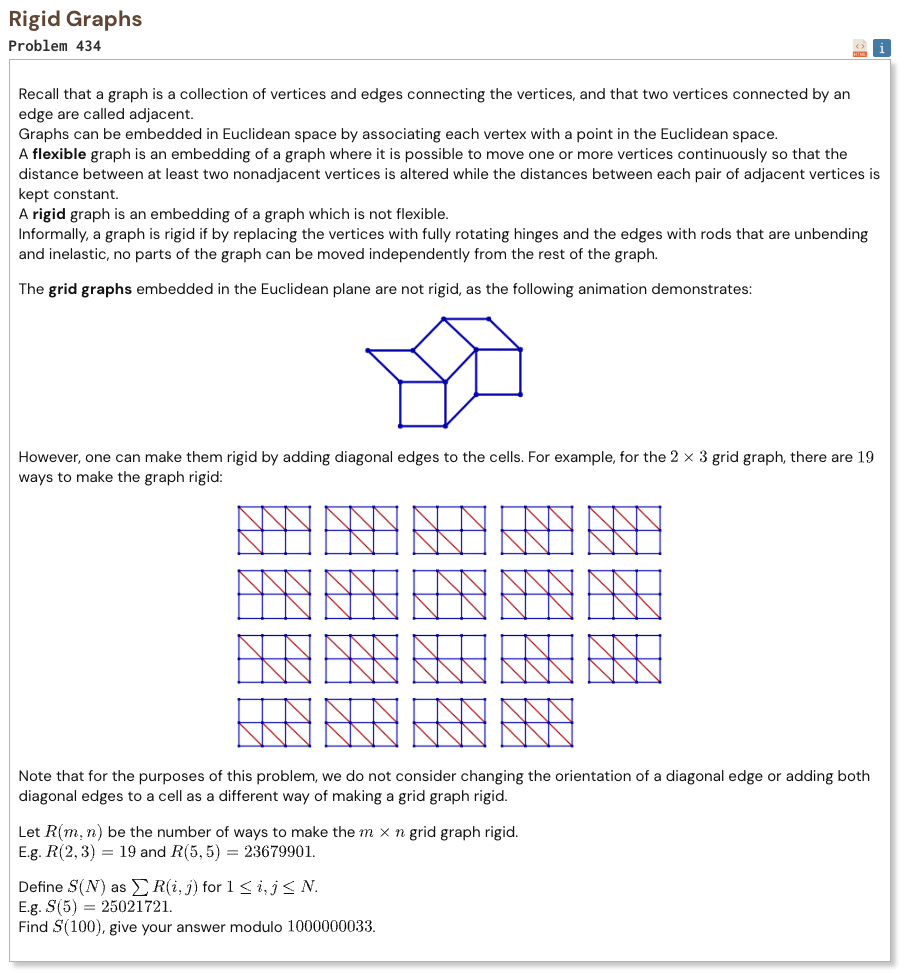

## Initial approach

-   treat every row and column of the grid as vertices of a bipartite graph
-   adding a diagonal to a cell creates an edge between its row and column
-   the grid becomes rigid exactly when this bipartite graph is connected
-   start with all possible choices of diagonal edges and subtract the disconnected cases
-   fix one row and count all possible connected components containing that row
-   use smaller already calculated grid sizes to build larger values with dynamic programming
-   precompute combinations and powers of two because they are used many times

In [1]:
%%time

from math import comb

MOD = 1_000_000_033
N = 100

choose = [[0] * (N + 1) for _ in range(N + 1)]

for n in range(N + 1):
    for k in range(n + 1):
        choose[n][k] = comb(n, k) % MOD

pow2 = [1] * (N * N + 1)

for i in range(1, N * N + 1):
    pow2[i] = pow2[i - 1] * 2 % MOD

R = [[0] * (N + 1) for _ in range(N + 1)]

R[1][0] = 1

for m in range(1, N + 1):
    for n in range(1, N + 1):
        value = pow2[m * n]

        for a in range(1, m):
            row_ways = choose[m - 1][a - 1]

            for b in range(n + 1):
                value -= (
                    row_ways
                    * choose[n][b]
                    * R[a][b]
                    * pow2[(m - a) * (n - b)]
                )

                value %= MOD

        for b in range(n):
            value -= choose[n][b] * R[m][b]
            value %= MOD

        R[m][n] = value

result = 0

for m in range(1, N + 1):
    for n in range(1, N + 1):
        result += R[m][n]

result %= MOD

print("Result:", result)

Result: 863253606
CPU times: user 5.94 s, sys: 24.8 ms, total: 5.97 s
Wall time: 6.03 s
